# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)



Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

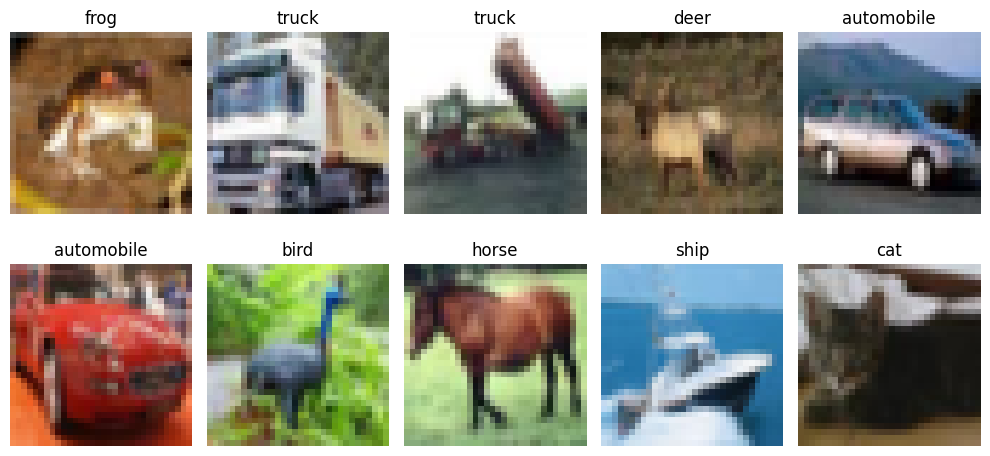

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
deep_ann_model = models.Sequential([
    layers.Dense(1024,
                 activation='relu',
                 input_shape=(3072,)),

    layers.Dropout(0.3),

    layers.Dense(512,
                 activation='relu'),

    layers.Dense(256,
                 activation='relu'),

    layers.Dense(128,
                 activation='relu'),

    layers.Dense(10,
                 activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.2703 - loss: 1.9788 - val_accuracy: 0.3306 - val_loss: 1.8401
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.3398 - loss: 1.8289 - val_accuracy: 0.3626 - val_loss: 1.7624
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.3582 - loss: 1.7691 - val_accuracy: 0.3736 - val_loss: 1.7399
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.3714 - loss: 1.7350 - val_accuracy: 0.4014 - val_loss: 1.6911
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3862 - loss: 1.6977 - val_accuracy: 0.4046 - val_loss: 1.6622
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.3963 - loss: 1.6699 - val_accuracy: 0.4294 - val_loss: 1.6274
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4040 - loss: 1.6479 - val_accuracy: 0.4286 - val_loss: 1.6434
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.4111 - loss: 1.6285 - 

In [6]:
deep_ann_loss, deep_ann_acc = deep_ann_model.evaluate(x_test_flat,y_test)
print("Deep ANN Accuracy:",deep_ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4697 - loss: 1.4916
Deep ANN Accuracy: 0.46970000863075256


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
better_cnn = models.Sequential([

    layers.Conv2D(
        64,
        3,
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        256,
        3,
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

better_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = better_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 173s 243ms/step - accuracy: 0.4794 - loss: 1.6682 - val_accuracy: 0.5704 - val_loss: 1.2293
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 172s 245ms/step - accuracy: 0.6292 - loss: 1.0665 - val_accuracy: 0.6364 - val_loss: 1.0561
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 192s 231ms/step - accuracy: 0.6901 - loss: 0.8902 - val_accuracy: 0.6586 - val_loss: 0.9675
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 233ms/step - accuracy: 0.7288 - loss: 0.7721 - val_accuracy: 0.6980 - val_loss: 0.9012
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 166s 236ms/step - accuracy: 0.7679 - loss: 0.6653 - val_accuracy: 0.7210 - val_loss: 0.8760
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 241ms/step - accuracy: 0.7927 - loss: 0.5913 - val_accuracy: 0.6932 - val_loss: 0.9439
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 236ms/step - accuracy: 0.8234 - loss: 0.5053 - val_accuracy: 0.6476 - val_loss: 1.3377
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 167s 237ms/step - accuracy: 0.8443 -

In [8]:
better_loss, better_acc = better_cnn.evaluate( x_test_norm, y_test)
print("Improved CNN Accuracy:",better_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7082 - loss: 0.9387
Improved CNN Accuracy: 0.7081999778747559


## 📈 Compare Learning Curves

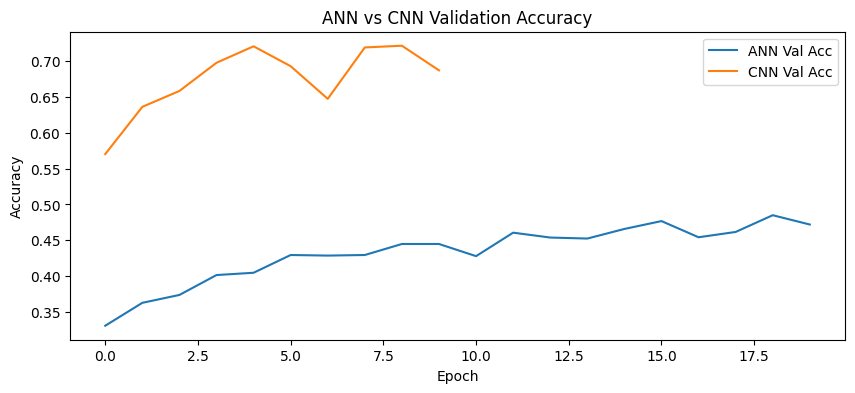

In [19]:
plt.figure(figsize=(10,4))
plt.plot(deep_ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(
        64,3,
        activation='relu',
        input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(
        128,3,
        activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(
        256,3,
        activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(
        256,
        activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(
        10,
        activation='softmax'
    )
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])


In [18]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:",
      aug_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 171s 238ms/step - accuracy: 0.4028 - loss: 1.8506 - val_accuracy: 0.4570 - val_loss: 1.6292
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 163s 231ms/step - accuracy: 0.5130 - loss: 1.3733 - val_accuracy: 0.5270 - val_loss: 1.4940
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 217s 252ms/step - accuracy: 0.5618 - loss: 1.2492 - val_accuracy: 0.5896 - val_loss: 1.1919
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 182s 259ms/step - accuracy: 0.5903 - loss: 1.1675 - val_accuracy: 0.6054 - val_loss: 1.1489
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 184s 261ms/step - accuracy: 0.6135 - loss: 1.1033 - val_accuracy: 0.6174 - val_loss: 1.1288
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.4441 - loss: 1.6153
Augmented CNN Accuracy: 0.4440999925136566


# 📊 Final Comparison Table

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "Deep ANN",
        "CNN",
        "Improved CNN",
        "Augmented CNN"
    ],

    "Expected Accuracy": [
        "40.19%",
        "45.01%",
        "71.64%",
        "71.26%",
        "74.15%"
    ],
})

comparison

,Model,Expected Accuracy
0,ANN,40.19%
1,Deep ANN,45.01%
2,CNN,71.64%
3,Improved CNN,71.26%
4,Augmented CNN,74.15%


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**